In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import readrbdata

In [2]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [81]:
# Fabry-Perot Calibration Model of the form

def fabry_time_to_freq(t, a: float, b: float, c: float, d: float, e: float):
    print(a, b, c, d, e)
    return np.array(a + b*t + c* t**2 + d* t**3 + e * t**4)


def read_scope_csv(filepath):
    # First pass: read header to get vertical scale
    vertical_scale = None
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if "Vertical Scale" in line:
                vertical_scale = float(line.strip().split(',')[1])
            if line.startswith("TIME"):
                header_line = i
                break

    if vertical_scale is None:
        raise ValueError("Vertical Scale not found in file")

    # Second pass: read actual data
    df = pd.read_csv(filepath, skiprows=header_line)

    # Scale the Y column (assumes second column is the signal)
    y_col = df.columns[1]
    df[y_col] = df[y_col] / vertical_scale

    return df

In [88]:
# # Load in all the data
name_dict = {
    "sat":{
        "mag":{
            "scan": "SatMagCh1Scan",
            "fabry": "SatMagCh2FabryPerot",
            "signal": "SatMagCh4Signal"
        },
        "nomag":{
            "scan": "SatCh1Scan",
            "fabry": "SatCh2FabryPerot",
            "signal": "SatCh4Signal"
        }
    },
    "unsat":{
        "mag":{
            "scan": "UnSatMagCh1Scan",
            "fabry": "UnSatMagCh2FabryPerot",
            "signal": "UnSatMagCh4Signal"
        },
        "nomag":{
            "scan": "UnSatCh1Scan",
            "fabry": "UnSatCh2FabryPerot",
            "signal": "UnSatCh4Signal"
        }
    }
}

# load and reformat data

names=[]
frames = []
data_dict = {}
for sat_type in ["saturated", "unsaturated"]:
    data_dict[sat_type]={}
    for mag_stat in ["magnet", "no_magnet"]:
        data_dict[sat_type][mag_stat]={}
        fab_fit_filename = f"./fabry_perot_fits/{sat_type}/{mag_stat}/theta.npy"
        fab_cov_filename = f"./fabry_perot_fits/{sat_type}/{mag_stat}/X.npy"

        data_dict[sat_type][mag_stat]["fab_fit"]=np.load(fab_fit_filename)
        data_dict[sat_type][mag_stat]["fab_cov"]=np.load(fab_cov_filename)

        dfs = []
        for dat_type in ["signal_gen", "fabry_perot", "data"]:
            filename = f"./data/{sat_type}/{mag_stat}/{dat_type}.CSV"
            names.append(f"{sat_type} {mag_stat} {dat_type}")
            df = read_scope_csv(filename)
            df = df.rename(columns={df.columns[0]: "time", df.columns[1]: dat_type})
            dfs.append(df.set_index("time"))
            # data_dict[sat_type][mag_stat][dat_type]=df
        merged_df = pd.concat(dfs, axis=1).reset_index()

        t = np.array(merged_df["time"])
        params = data_dict[sat_type][mag_stat]["fab_fit"]
        freq = fabry_time_to_freq(t, *params)
        merged_df["freq"]=freq
        data_dict[sat_type][mag_stat]["data"]=merged_df
        print(merged_df)

print(names)

2.253233467083831 69.84205200306647 137.73765697754885 -1299.5654171378264 5082.43429206028
           time  signal_gen   fabry_perot  data      freq
0     -0.068800        1.80  5.000000e-02  7.70 -1.362835
1     -0.068792        1.75  1.000000e-01  7.70 -1.362629
2     -0.068784        1.80  5.000000e-02  7.70 -1.362422
3     -0.068776        1.80  5.000000e-02  7.70 -1.362215
4     -0.068768        1.80  1.000000e-01  7.70 -1.362009
...         ...         ...           ...   ...       ...
19995  0.091160        5.00  1.500000e-01  7.20  9.131151
19996  0.091168        5.00  1.000000e-01  7.20  9.131774
19997  0.091176        5.00  5.000000e-02  7.20  9.132398
19998  0.091184        5.05  2.384185e-08  7.15  9.133022
19999  0.091192        5.00  1.500000e-01  7.20  9.133645

[20000 rows x 5 columns]
2.3318533572668447 70.30156755131082 123.37945020661813 -1519.4072145536866 11557.753722523697
           time  signal_gen   fabry_perot  data      freq
0     -0.068800        1.80  5.00

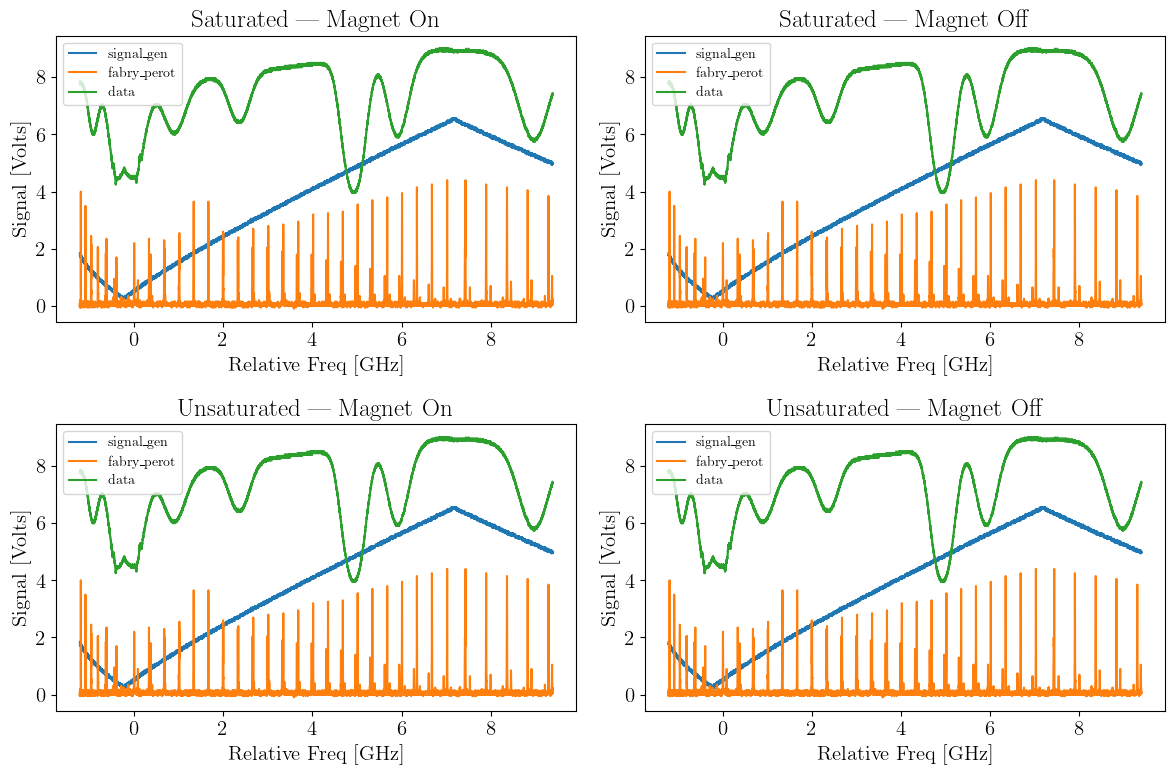

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # easier indexing

subplot_idx = 0

for sat_type in data_dict.keys():
    for mag_stat in data_dict[sat_type].keys():
        ax = axes[subplot_idx]
        data_dfs = []
        df = data_dict[sat_type][mag_stat]["data"]
        for col in ["signal_gen", "fabry_perot", "data"]:
            ax.plot(merged_df["freq"], merged_df[col], label=col)

        ax.set_title(f"{sat_type.capitalize()} | {"Magnet On" if mag_stat=="magnet" else "Magnet Off"}")
        ax.set_xlabel("Relative Freq [GHz]")
        ax.set_ylabel("Signal [Volts]")
        ax.legend(fontsize=10)
        
        subplot_idx += 1


plt.tight_layout()
plt.savefig("DataSummary.png")
plt.show()

2.253233467083831 69.84205200306647 137.73765697754885 -1299.5654171378264 5082.43429206028
2.3318533572668447 70.30156755131082 123.37945020661813 -1519.4072145536866 11557.753722523697
2.2223491455923803 69.81907036836304 141.23334086476606 -1296.7743811929881 4191.333332706976
2.318056822394664 70.32176887148444 123.2602736507511 -1461.8169211818931 10724.17938937254


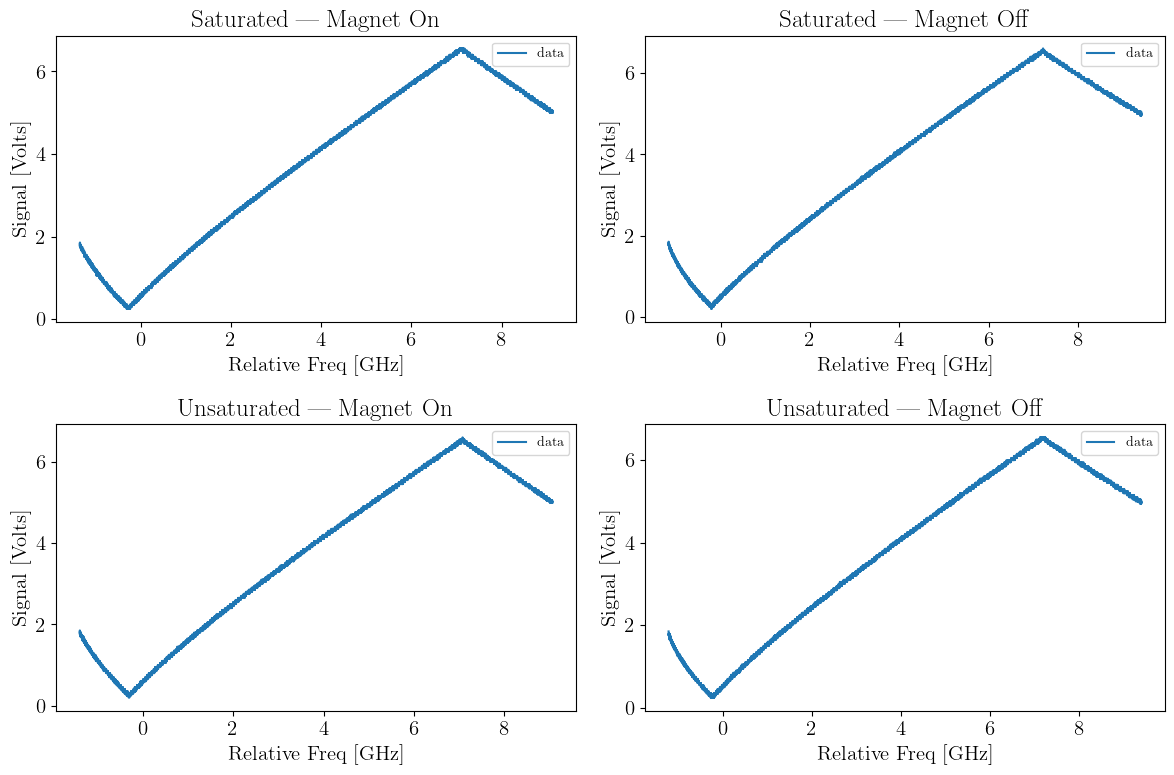

In [ ]:
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes = axes.flatten()  # easier indexing

# subplot_idx = 0

# for sat_type in data_dict.keys():
#     for mag_stat in data_dict[sat_type].keys():
#         ax = axes[subplot_idx]
#         for dat_type in data_dict[sat_type][mag_stat].keys():
#             if dat_type=="fab_fit" or dat_type=="fab_cov" or dat_type=="fabry_perot":
#                 continue
#             df = data_dict[sat_type][mag_stat][dat_type]
#             # assuming columns are named 'time' and 'signal'
#             ax.plot(fabry_time_to_freq(np.asarray(df.iloc[:, 0]), *data_dict[sat_type][mag_stat]["fab_fit"]), df.iloc[:, 1], label=dat_type)
        
#         ax.set_title(f"{sat_type.capitalize()} | {"Magnet On" if mag_stat=="magnet" else "Magnet Off"}")
#         ax.set_xlabel("Relative Freq [GHz]")
#         ax.set_ylabel("Signal [Volts]")
#         ax.legend(fontsize=10)
        
#         subplot_idx += 1

# plt.tight_layout()
# plt.savefig("DataSummary.png")
# plt.show()

Text(0.5, 0, 'Time')

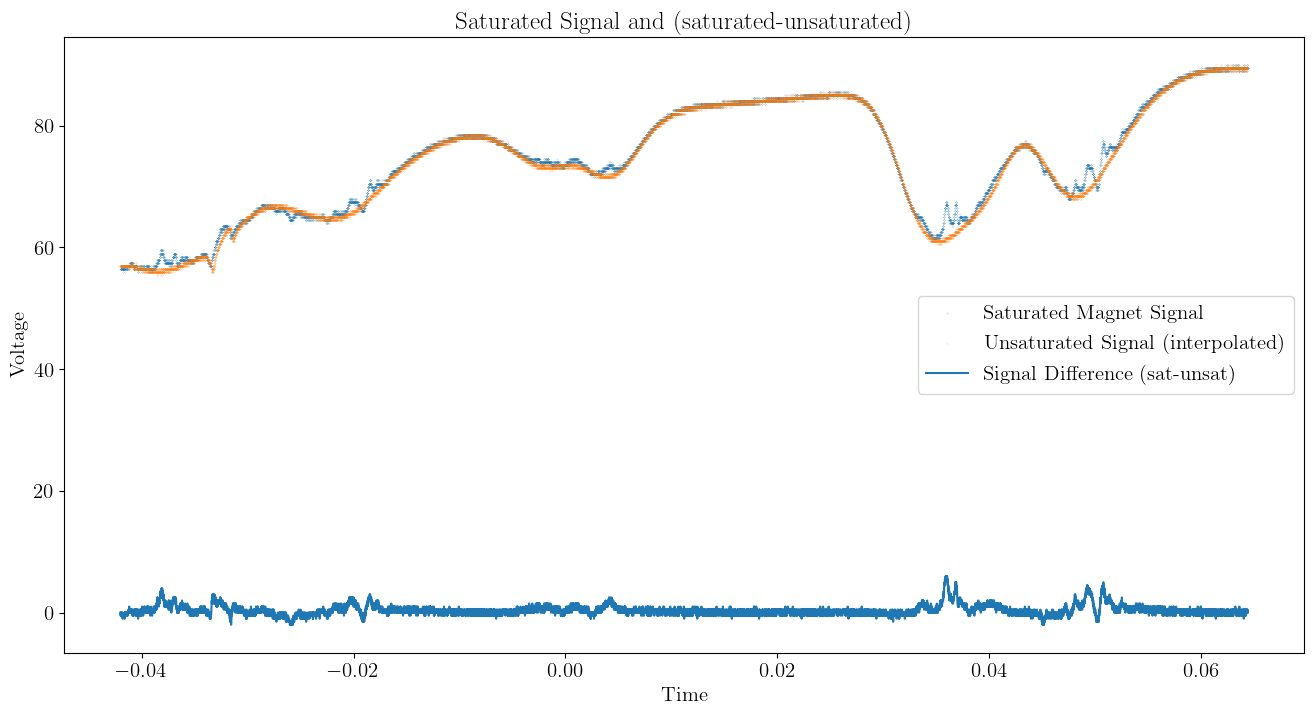

In [7]:
div=.01
satmag = readrbdata.load(sat=True, mag=True)
unsatmag = readrbdata.load(sat=False, mag=True)

uns_interp = np.interp(satmag.time, unsatmag.time, unsatmag.signal)
fig, ax = plt.subplots(figsize=(16,8))
ax.scatter(satmag.time, satmag.signal, label="Saturated Magnet Signal", s=.01)
ax.scatter(satmag.time, uns_interp, label="Unsaturated Signal (interpolated)", s=.01)
ax.plot(satmag.time, satmag.signal - uns_interp, label="Signal Difference (sat-unsat)")
ax.set_title("Saturated Signal and (saturated-unsaturated)")
ax.legend()
ax.set_ylabel("Voltage")
ax.set_xlabel("Time")

# plt.figure(figsize=(16,8))
# plt.scatter(satmag.time, np.asarray(satmag.signal)*div, s=.1)
# plt.scatter(unsatmag.time, np.asarray(unsatmag.signal)*div, s=.1)
# plt.legend(["Saturated Magnet", "Unsaturated Magnet"], markerscale=15)


In [ ]:
def absorption_model(x, x0, a, b, c, d):
    return a * np.exp(-b * (x - x0)**2) + c * x + d

print(absorption_model(1.5, 1, 1, 1, 0, 0))

0.7788007830714049


In [ ]:
unsat = readrbdata.load(sat=False, mag=False)

p0: [np.float64(-0.021792), np.float64(-17.0), 1.037235, 0.1, 85]


Fitted parameters:
x0 = -0.02095223383132999
a  = -15.730391108951752
b  = 37781.131662375315
c  = 310.73602044523557
d  = 82.65756208335829
p0: [np.float64(-0.000176), np.float64(-16.0), 1.037235, 0.1, 85]
Fitted parameters:
x0 = 0.0006047794928182448
a  = -17.783065146736668
b  = 45495.19450325522
c  = 209.277475855514
d  = 81.73770581813861
p0: [np.float64(0.035112), np.float64(-37.5), 1.037235, 0.1, 85]
Fitted parameters:
x0 = 0.03562276264810106
a  = -64.82234970499445
b  = 27755.269940435635
c  = 217.88589690767705
d  = 96.22743105539769
p0: [np.float64(0.04808), np.float64(-29.5), 1.037235, 0.1, 85]
Fitted parameters:
x0 = 0.04853434592193884
a  = -28.757444009823942
b  = 52819.881325114715
c  = 64.95837409938946
d  = 84.93900244565022


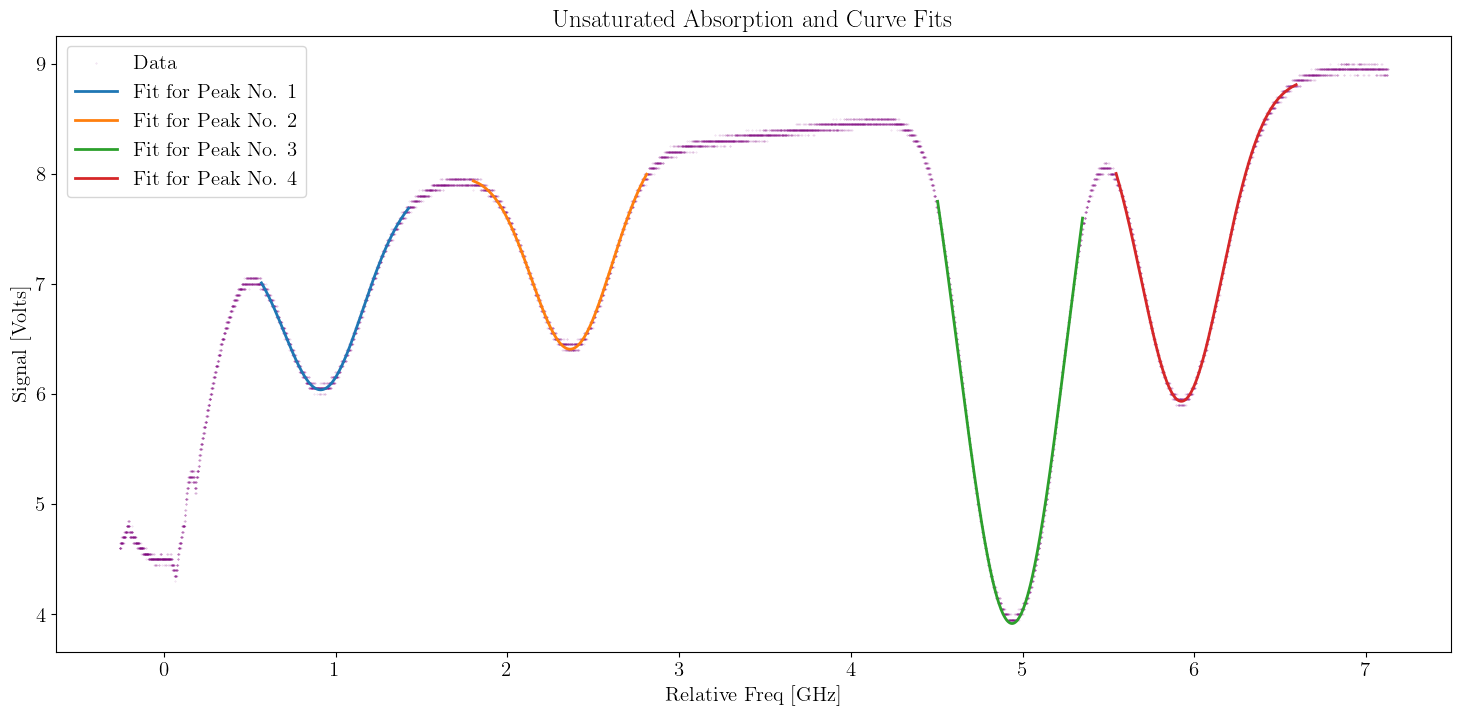

In [ ]:
plt.figure(figsize=(18, 8))
plt.scatter(fabry_time_to_freq(unsat.time, *data_dict["saturated"]["no_magnet"]["fab_fit"]), unsat.signal*.1, s=.1, alpha=.2, c="purple", label="Data")

centers=[2750, 5200, 9680, 11550]
window_sizes=[1700, 1800, 1400, 1700]
for i in range(4):
    start=centers[i] - int (window_sizes[i]/2)
    stop=centers[i] + int (window_sizes[i]/2)


    xdata = unsat.time[start:stop]
    ydata = unsat.signal[start:stop]

    #  model: a * np.exp(-b * (x - x0)**2) + c * x + d

    # initial guesses
    x0_guess = xdata[np.argmin(ydata)]   # center at minimum
    a_guess = np.min(ydata) - np.max(ydata)   # negative dip amplitude
    b_guess = 1.037235
    c_guess = 0.1
    d_guess = 85 # np.max(ydata)

    p0 = [x0_guess, a_guess, b_guess, c_guess, d_guess]
    print(f"p0: {p0}")
    # optional bounds
    bounds = (
        [xdata.min(), -np.inf, 0, -np.inf, -np.inf],   # lower
        [xdata.max(), 0,      np.inf, np.inf,  np.inf] # upper
    )

    popt, pcov = scipy.optimize.curve_fit(
        absorption_model,
        xdata,
        ydata,
        p0=p0,
        bounds=bounds,
        maxfev=10000
    )

    # fitted parameters
    x0_fit, a_fit, b_fit, c_fit, d_fit = popt
    print("Fitted parameters:")
    print(f"x0 = {x0_fit}")
    print(f"a  = {a_fit}")
    print(f"b  = {b_fit}")
    print(f"c  = {c_fit}")
    print(f"d  = {d_fit}")

    # print(f"Covariance: {pcov}")

    # fitted curve
    xfit = np.linspace(xdata.min(), xdata.max(), 2000)
    yfit = absorption_model(xfit, *popt)
    # for shadeline in range(100):
    #     plt.plot(xfit, .01*absorption_model(xfit, *np.random.multivariate_normal(popt, 100*pcov)), alpha=.1, c="orange")
    plt.plot(fabry_time_to_freq(xfit, *data_dict["saturated"]["no_magnet"]["fab_fit"]), yfit*.1, linewidth=2, label=f"Fit for Peak No. {i+1}")

plt.xlabel("Relative Freq [GHz]")
plt.ylabel("Signal [Volts]")
plt.title("Unsaturated Absorption and Curve Fits")
plt.legend()
plt.savefig("DopplerFits.png")
plt.show()

# plt.figure(figsize=(18,8))
# # satnonmagsignal = data_dict['sat']['nomag']['signal']
# # unsatnonmagsignal = data_dict['unsat']['nomag']['signal']
# plt.title("Non-Saturated Absorption")
# plt.xlabel("Time")
# plt.ylabel("Voltage")
# plt.scatter(unsat.time[start:stop], (unsat.signal)[start:stop],s=.1)
# # plt.scatter(tps_times, tps_vals, s=20)


# scipy.optimize.curve_fit(absorption_model, unsat.time[start:stop], unsat.signal[start:stop], p0=[.0355, -1, 1, 0, .9])

Expect absorption to be $$g(\omega)=\frac{c}{u \omega_0 \sqrt{\pi}}\text{exp}\left(-\frac{c^2}{u^2}\left(\frac{\omega - \omega_0}{\omega_0}\right)^2\right)$$

Which means that the Transmittance would be the inverse:

$$T(\omega)=V_{0}-A\frac{c}{u \omega_0 \sqrt{\pi}}\text{exp}\left(-\frac{c^2}{u^2}\left(\frac{\omega - \omega_0}{\omega_0}\right)^2\right)$$


In [19]:

# Chamber temp
chamber_temp = 45.2
v_laser = 5
# scan freq
c=299792458
k_b=1.38065e-23
T=273.15 + chamber_temp
N_a = 6.022e23
m85_amu = 84.91
m87_amu = 86.91
m85_kg = m85_amu / (N_a*1000)
m87_kg = m87_amu / (N_a*1000)

u85 = np.sqrt(2*k_b*T / m85_kg)
u87 = np.sqrt(2*k_b*T / m87_kg)
omega_0=c/750e-9
print(f"m85_kg: {m85_kg}\nu85: {u85}\nc: {c} m/s\n")
print(f"m87_kg: {m87_kg}\nu87: {u87}\nc: {c} m/s\n")

# The width of the doppler broadened distribution is somewhere in the range of several hundred megahertz. For a resonant frequency of c/750e-9, we expect to see the absorption spectrum from c/750e-9+-560MHz (FWHM)
# This translates to frequencies of between 3.997 227 173 33e14 to 3.997 238 373 33e14 Hz. 

# freq_vals = np.linspace(c/(c/750e-9-560e6), c/(c/750e-9+560e6), 1000)

m85_kg: 1.4099966788442375e-25
u85: 249.68944193979328
c: 299792458 m/s

m87_kg: 1.4432082364662901e-25
u87: 246.7997549674793
c: 299792458 m/s



In [ ]:
# Implement  in SI units
def g_d(omega, c, u, omega_0):
    scale = (c / (u * omega_0 * np.sqrt(np.pi)))
    print(scale)
    exp_scale = -c**2/(u**2)
    #print(f"Exp scale: {exp_scale}")
    exp_val = ((omega-omega_0)/omega_0)**2
    #print(f"Exp val: {exp_val}")
    exp = np.exp(- (c**2 / u**2) * ((omega - omega_0) / omega_0)**2)
    #print(f"Exp: {exp}")
    return scale*exp
print(f"Frequency of light with wavelength 750nm: {c/750e-9:.4g} Hz")
print(g_d(c/750e-9, c, u85, omega_0))


Frequency of light with wavelength 750nm: 3.997e+14 Hz
1.6946739292358545e-09
1.694612770222251e-09


In [ ]:
# pred_abs = np.zeros_like(freq_vals)
# for i in range(len(pred_abs)):
#     pred_abs[i]=g_d(c/freq_vals[i], c, u85, omega_0)

# print(freq_vals)
# print(pred_abs)
# plt.scatter(freq_vals, pred_abs)

In [ ]:
dp_broadened = pd.read_csv("TEK00074.CSV", skiprows=15)
dp_broadened.head(20)

In [ ]:
plt.figure(figsize=(18, 6))
plt.ylabel("Volts")
plt.xlabel("Time")
plt.plot(dp_broadened["TIME"], dp_broadened["CH4"]/100)


In [ ]:
sat_abs = pd.read_csv("TEK00071.CSV", skiprows=15)
plt.figure(figsize=(18,6))
plt.xlabel("Time"); plt.ylabel("Volts")
plt.plot(sat_abs["TIME"], sat_abs["CH4"]/100)